In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install sqlalchemy
%pip install scikit-learn
%pip install python-dotenv
%pip install psycopg2-binary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sqlalchemy import create_engine, URL


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------------------ --------------------- 1.3/2.8 MB 13.2 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 13.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import psycopg2

print(psycopg2.__version__)

2.9.13 (dt dec pq3 ext lo64)


In [3]:
# Get connection to DB

from pathlib import Path
from dotenv import load_dotenv

#Get env varibles from FetchData folder
env_path = Path("../../Fetch_Data/.env").resolve()
load_dotenv(env_path)

# Verify correct Path
print(env_path)
print(env_path.exists())

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT", "5433")),
    database=os.getenv("POSTGRES_DB")
)

engine = create_engine(url)

test_query = """
SELECT pokemon_name
FROM pokemon
"""

df = pd.read_sql(test_query, engine)
print(df.head())

C:\Users\brice\OneDrive\Documents\Projects\Pokemon_VGC\Pokemon_VGC_Analysis\Fetch_Data\.env
True
  pokemon_name
0    bulbasaur
1      ivysaur
2     venusaur
3   charmander
4   charmeleon


# Phase 1:

- Use logistical Regression to predict whether a team will make top cup (In this case defined as **top 10%**)
- First step consider a sub select of pokemon using one-hot encoding
    - Decide which pokemon to use via usage rates (only consider the most popular pokemon)
- Make different predictors per each regulation

## Example Encoding

| pk_1  | pk_2     | top_10%  |
|-------|----------|----------|
| 1     | 0        | 1        |
| 1     | 1        |0         |



In [57]:
from sqlalchemy import text


sql_path = Path("../../analysis/top_10_per_reg.sql").resolve()

with open(sql_path, "r") as file:
    query = text(file.read())
    
regulation = "I"
num_pokemon = 100
min_event_size = 60




top_n_usage = pd.read_sql(
    query,
    engine,
    params={
        "regulation" : regulation,
        "num_pokemon" : num_pokemon,
        "min_event_size" : min_event_size
    }
)

top_names = top_n_usage["pokemon_name"].tolist()
print(top_names)


team_query = text("""
    SELECT
        t.team_id,
        t.placement,
        p.pokemon_name,
        e.event_id,
        e.event_size
    FROM teams t
    JOIN events e
        ON t.event_id = e.event_id
    JOIN team_pokemon tp
        ON t.team_id = tp.team_id
    JOIN pokemon p
        ON tp.pk_id = p.pk_id
    WHERE e.regulation = :regulation;
""")


team_pokemon = pd.read_sql(
    team_query,
    engine,
    params={
        "regulation" : regulation
    }
)


# Get all Team_id's from regulation
all_team_ids = team_pokemon["team_id"].unique()

# Get rid of non-top_n pokemon, because that data is not helpful this model
filtered = team_pokemon[team_pokemon["pokemon_name"].isin(top_names)]



# Use cross tab in order to get a count of pokemon per team id
ml_df = pd.crosstab(
    filtered["team_id"],
    filtered["pokemon_name"]
)

# Then get information about each team and where they placed
team_results = (
    team_pokemon[
        ["team_id", "placement", "event_id", "event_size"]
    ]
    .drop_duplicates()
    .set_index("team_id")
)

# Get teams that places in the top 10%
team_results["made_top_cut"] = (
    (
    team_results["placement"] <=  32
    ).astype(int)
)

# Then Ensure that everythin is in binary, in the rare case where it number > 1
ml_df = (ml_df > 0).astype(int)

# Reindex for teams that may not have any of the top N
# Also change df to desired columns 
ml_df = ml_df.reindex(
    index=all_team_ids,
    columns=top_names,
    fill_value=0
)

# Join this table with the made top 10 table
ml_df = ml_df.join(team_results["made_top_cut"])



['incineroar', 'miraidon', 'calyrex-shadow', 'zamazenta', 'urshifu-rapid-strike', 'calyrex-ice', 'amoonguss', 'raging-bolt', 'rillaboom', 'chien-pao', 'koraidon', 'lunala', 'iron-hands', 'whimsicott', 'flutter-mane', 'chi-yu', 'ursaluna', 'grimmsnarl', 'kyogre', 'farigiraf', 'terapagos', 'volcarona', 'smeargle', 'brute-bonnet', 'landorus-therian', 'ogerpon-hearthflame-mask', 'tornadus-incarnate', 'ogerpon-cornerstone-mask', 'dragonite', 'iron-treads', 'zacian', 'weezing-galar', 'indeedee-female', 'roaring-moon', 'sinistcha', 'ogerpon-wellspring-mask', 'urshifu-single-strike', 'clefairy', 'groudon', 'ho-oh', 'ditto', 'iron-bundle', 'ting-lu', 'annihilape', 'walking-wake', 'jumpluff', 'sneasler', 'iron-jugulis', 'pelipper', 'toxapex', 'dondozo', 'entei', 'tatsugiri-droopy', 'ursaluna-bloodmoon', 'iron-valiant', 'torkoal', 'basculegion-male', 'kingambit', 'chesnaught', 'maushold-family-of-three', 'tsareena', 'raichu', 'iron-moth', 'giratina-origin', 'rhydon', 'scream-tail', 'overqwil', 'g

made_top_cut
0    584
1    433
Name: count, dtype: int64

Percentages:
made_top_cut
0    0.574238
1    0.425762
Name: proportion, dtype: float64
True Negatives: 89
False Positives: 28
False Negatives: 50
True Positives: 37
Accuracy:  0.6176470588235294
Recall:  0.42528735632183906
Precision:  0.5692307692307692


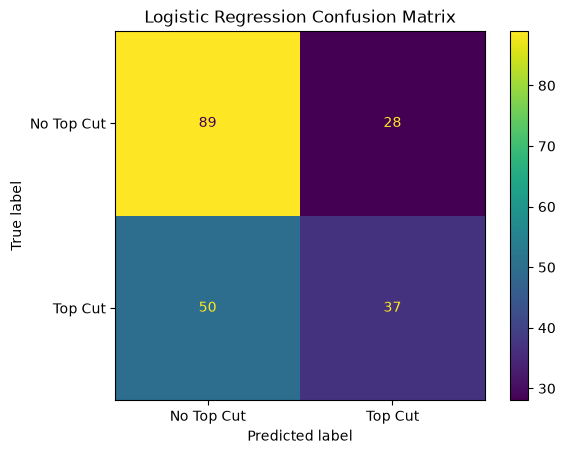

In [58]:



from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Seperate into X and Y data
X = ml_df.drop(columns=["made_top_cut"])
y = ml_df["made_top_cut"]

print(y.value_counts())

print("\nPercentages:")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42,
    stratify=y
)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
probabilities = model.predict_proba(X_test)


from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)


# Get results:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

accuracy = (tn + tp) / (tn + tp + fn + fp)
recall = tp / (tp + fn)
precison = tp / (tp + fp)

print("Accuracy: ",  accuracy)
print("Recall: ", recall)
print("Precision: ", precison)

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Top Cut", "Top Cut"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Model Experiment Log

## Experiment Information

**Model:** Logistic Regression  
**Target:** Top 32 Finish  
**Training/Test Split:** 80% / 20%  
**Random State:** 42  
**Number of Pokemon Features: N**  
**Regulations: I**
**Number of Teams:** 1017  

---

## Class Distribution

| Class | Count | Percentage |
|---|---:|---:|
| No Top Cut (0) | 584 | 57.42% |
| Top Cut (1) | 433 | 42.58% |



---

## Confusion Matrix
### N = 10
|  | Predicted No Top Cut | Predicted Top Cut |
|---|---:|---:|
| **Actual No Top Cut** | TN = 100 | FP = 17 |
| **Actual Top Cut** | FN = 65 | TP =  22 |
Accuracy: 57.3%

## Confusion Matrix
### N = 25
|  | Predicted No Top Cut | Predicted Top Cut |
|---|---:|---:|
| **Actual No Top Cut** | TN = 83 | FP = 34 |
| **Actual Top Cut** | FN = 53 | TP =  34 |
Accuracy:  57.3%

## Confusion Matrix
### N = 50
|  | Predicted No Top Cut | Predicted Top Cut |
|---|---:|---:|
| **Actual No Top Cut** | TN = 90 | FP = 27 |
| **Actual Top Cut** | FN = 52 | TP =  35 |
Accuracy:  61.3%

## Confusion Matrix
### N = 100
|  | Predicted No Top Cut | Predicted Top Cut |
|---|---:|---:|
| **Actual No Top Cut** | TN = 89 | FP = 28 |
| **Actual Top Cut** | FN = 50 | TP =  37 |
Accuracy:  61.8%

---

## Conclusion
This model only functions slightly above guessing the majority class
This model does not take into account team synergy it just attempts to see patterns across data
It also does not take into account moves, items, tera types, players, metagame etc. 


# Phase 2: Random Forrest

- Use Random Forrest instead of logistical regression because the random forrest can find patterns between data
    - For examples it may find that when a team has all three certain pokemon it may do better
    - essentially it is finding syngergy between the pokemon 


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Seperate into X and Y data
X = ml_df.drop(columns=["made_top_cut"])
y = ml_df["made_top_cut"]

print(y.value_counts())

print("\nPercentages:")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100
    random_state=42
)